Made By Abaan Iqbal

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

pd.options.display.float_format = '{:.2f}'.format

qSales = pd.read_csv('qSales_2024.csv')



In [ ]:
qSales = pd.read_csv('qSales_2024.csv')
qSales['datadate'] = pd.to_datetime(qSales['datadate'])

target_sales = qSales.loc[qSales['tic'] == 'TGT'].copy()
target_sales = target_sales.sort_values('datadate').reset_index(drop=True)

display(target_sales)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat
0,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.00,A
1,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.00,A
2,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.00,A
3,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.00,A
4,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.00,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,31395.00,A
89,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,25322.00,A
90,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,24773.00,A
91,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,25398.00,A


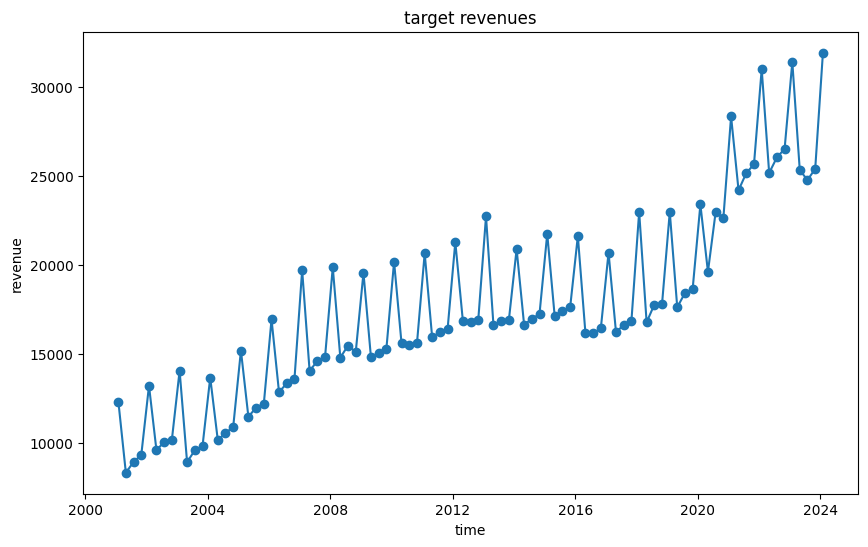

In [ ]:
plt.figure(figsize=(10,6))
plt.title('target revenues')
plt.xlabel('time')
plt.ylabel('revenue')
plt.plot(target_sales['datadate'], target_sales['saleq'], marker='o')



In [ ]:
display(target_sales.groupby('fqtr')['saleq'].mean())

,saleq
fqtr,
1,15868.43
2,16407.65
3,16608.22
4,21099.46


In [ ]:
target_sales['time'] = range(1, len(target_sales) + 1)
target_sales

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time
0,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.00,A,1
1,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.00,A,2
2,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.00,A,3
3,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.00,A,4
4,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.00,A,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,31395.00,A,89
89,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,25322.00,A,90
90,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,24773.00,A,91
91,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,25398.00,A,92


In [ ]:
#  Q4 (holiday) and Q1 (post-holiday)
target_sales['q4_dummy'] = np.where(target_sales['fqtr'] == 4, 1, 0)   # holiday quarter
target_sales['q1_dummy'] = np.where(target_sales['fqtr'] == 1, 1, 0)   # post-holiday quarter
display(target_sales)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time,q4_dummy,q1_dummy
0,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.00,A,1,1,0
1,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.00,A,2,0,1
2,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.00,A,3,0,0
3,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.00,A,4,0,0
4,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.00,A,5,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,31395.00,A,89,1,0
89,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,25322.00,A,90,0,1
90,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,24773.00,A,91,0,0
91,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,25398.00,A,92,0,0


In [ ]:
x = target_sales.loc[:, ['time', 'q4_dummy', 'q1_dummy']]
x = sm.add_constant(x)

y = target_sales.loc[:, 'saleq']

model1 = sm.OLS(y, x).fit()
model1.params

,0
const,8490.51
time,168.79
q4_dummy,4675.92
q1_dummy,-386.32


In [ ]:
# target revenue = 8,491 + 169 * time + 4,676 * q4_dummy + (-386) * q1_dummy

In [ ]:
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  saleq   R-squared:                       0.894
Model:                            OLS   Adj. R-squared:                  0.891
Method:                 Least Squares   F-statistic:                     251.3
Date:                Fri, 24 Jul 2026   Prob (F-statistic):           2.55e-43
Time:                        21:38:54   Log-Likelihood:                -824.72
No. Observations:                  93   AIC:                             1657.
Df Residuals:                      89   BIC:                             1668.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       8490.5060    413.481     20.534      0.000    7668.928    9312.084
time         168.7880      6.786     24.872      0.000     155.304     182.272
q4_dummy    4675.9175    442.279     10.572      0.000    3797.118    5554.717
q1_dummy    -386.3180    448.655     -0.861      0.392   -1277.786     505.150
==============================================================================
Omnibus:                        2.541   Durbin-Watson:                   0.152
Prob(Omnibus):                  0.281   Jarque-Bera (JB):                1.985
Skew:                          -0.205   Prob(JB):                        0.371
Kurtosis:                       2.413   Cond. No.                         170.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

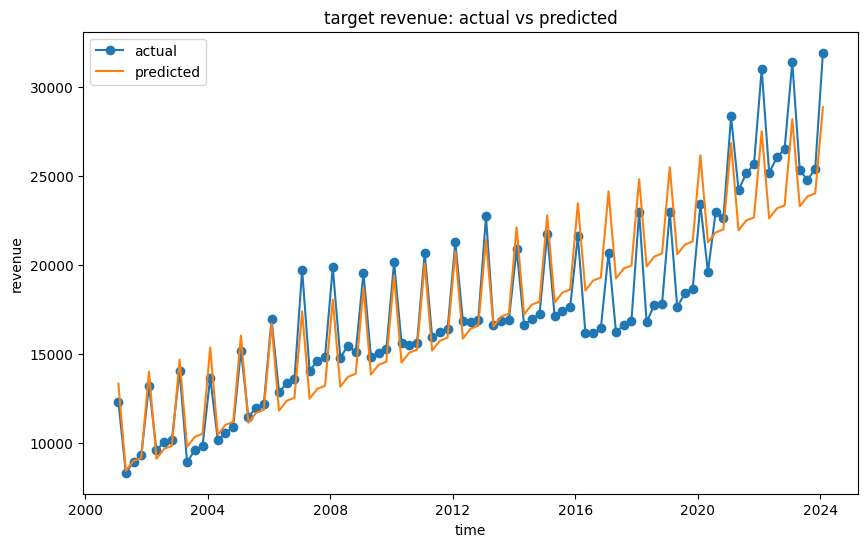

In [ ]:
target_sales['predicted'] = model1.predict(x)

plt.figure(figsize=(10,6))
plt.title('target revenue: actual vs predicted')
plt.xlabel('time')
plt.ylabel('revenue')
plt.plot(target_sales['datadate'], target_sales['saleq'], marker='o', label='actual')
plt.plot(target_sales['datadate'], target_sales['predicted'], label='predicted')
plt.legend()

In [ ]:
# synthetic future data for the next 4 quarters
n = len(target_sales)
last_date = target_sales['datadate'].max()
last_fqtr = int(target_sales['fqtr'].iloc[-1])

synth_data = pd.DataFrame({
    'datadate': pd.date_range(last_date, periods=5, freq=pd.offsets.QuarterEnd(startingMonth=1))[1:],
    'time': range(n + 1, n + 5)
})
synth_data['fqtr'] = [((last_fqtr - 1 + i) % 4) + 1 for i in range(1, 5)]
synth_data['q4_dummy'] = np.where(synth_data['fqtr'] == 4, 1, 0)
synth_data['q1_dummy'] = np.where(synth_data['fqtr'] == 1, 1, 0)
display(synth_data)

,datadate,time,fqtr,q4_dummy,q1_dummy
0,2024-04-30,94,1,0,1
1,2024-07-31,95,2,0,0
2,2024-10-31,96,3,0,0
3,2025-01-31,97,4,1,0


In [ ]:
x_future = synth_data.loc[:, ['time', 'q4_dummy', 'q1_dummy']]
x_future = sm.add_constant(x_future, has_constant='add')

model1.get_prediction(x_future).summary_frame(alpha=0.2)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,23970.26,490.13,23337.43,24603.08,21615.89,26324.63
1,24525.36,413.48,23991.50,25059.22,22195.64,26855.09
2,24694.15,418.79,24153.43,25234.87,22362.85,27025.45
3,29538.86,493.63,28901.52,30176.19,27183.27,31894.45


##MEMO
To: Chapman Wealth Management
From: QuantFolio Solutions - Abaan Iqbal
Date: July 24, 2026
Re: Target Corporation quarterly revenue patterns

We built a regression model that explains revenue using a time trend and two seasonal indicator, we determined that Target's revenue is predictable and growing. Steady long-term growth is visible and consistent for future predictions.

The two dummy variables show a holiday and post-holiday indicator covering (Q4 Nov-Jan and Q1 Feb-Apr) respectibely and are measured against Q2 and Q3 which are spring and summer. The dummy variables show that Target's year is steady with a peak in holiday and then dips back down after it.

The model fits the data well, explaining about 89 percent of the variation in Target's quartleryy revenue and the predictions land within 8 percent of the actual revenue,

The model does a good job of describing the revenue patterns of target's and descrbes its long-term growth well. One key insight for Chapman would be to uncover the earnings specifically in the holiday season as that is their peak because a slow holiday would be a sign of decline for target wheras it might be normal in the spring time.